# 📈 FinSentBERT — Reading the Market's Mood with BERT
### Fine-tuning a pre-trained BERT model to classify financial tweets as **Bearish 🐻 / Bullish 🐂 / Neutral ➖**


**Why this dataset?** Most BERT demos use IMDb movie reviews. Financial text is far harder: the same word flips meaning with context (*"cut"* costs → good, *"cut"* guidance → bad), tweets are full of tickers like `$TSLA`, and the classes are **imbalanced**. This makes it a realistic test of what transfer learning actually buys us.

**Dataset:** [`zeroshot/twitter-financial-news-sentiment`](https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment) — ~11,900 English finance tweets annotated as Bearish (0), Bullish (1), Neutral (2).

### What this notebook does
1. Exploratory data analysis of financial language
2. A classical **TF-IDF + Logistic Regression baseline** (so BERT has something to beat)
3. Fine-tunes **`bert-base-uncased`** with a **class-weighted loss** for imbalance
4. Evaluates with accuracy, macro-F1, per-class report and confusion matrix
5. Visualises how fine-tuning reshapes BERT's **[CLS] embedding space** (t-SNE, before vs after)
6. **Explainability**: highlights which words BERT attends to
7. **Error analysis** of BERT's most confident mistakes
8. A live **Gradio web demo**

> ⚙️ **Runtime → Change runtime type → T4 GPU** before running. Full run takes about 10 minutes.

## 1. Setup

In [1]:
!pip install -q -U transformers datasets accelerate gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 3.7 MB/s eta 0:00:00


In [2]:
import os, re, random, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from datasets import load_dataset, Dataset
from transformers import (AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding, set_seed)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import HTML, display

warnings.filterwarnings("ignore")
os.environ["WANDB_DISABLED"] = "true"

SEED = 42
set_seed(SEED); random.seed(SEED); np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only (training will be slow!)")

sns.set_theme(style="whitegrid", palette="muted")
LABELS = {0: "Bearish 🐻", 1: "Bullish 🐂", 2: "Neutral ➖"}
SHORT = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
COLORS = {0: "#e74c3c", 1: "#27ae60", 2: "#7f8c8d"}

Device: cuda | Tesla T4


## 2. Load the dataset

In [3]:
raw = load_dataset("zeroshot/twitter-financial-news-sentiment")
print(raw)

def clean(t):
    t = re.sub(r"https?://\S+", "", t)      # drop URLs (they carry no sentiment)
    return re.sub(r"\s+", " ", t).strip()

full_train = raw["train"].to_pandas()
test_df    = raw["validation"].to_pandas()      # official held-out split -> our TEST set
for d in (full_train, test_df):
    d["text"] = d["text"].map(clean)

# carve a stratified validation set out of train for model selection
train_df, val_df = train_test_split(full_train, test_size=0.1, stratify=full_train["label"], random_state=SEED)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_df.sample(8, random_state=1).assign(sentiment=lambda d: d.label.map(LABELS))[["text", "sentiment"]]

README.md:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

sent_train.csv:   0%|          | 0.00/859k [00:00<?, ?B/s]

sent_valid.csv:   0%|          | 0.00/217k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})
Train: 8588 | Val: 955 | Test: 2388


,text,sentiment
2693,Edited Transcript of BREW earnings conference ...,Neutral ➖
517,Cleveland Fed President Says Coronavirus Requi...,Neutral ➖
116,Target Hospitality downgraded to perform from ...,Bearish 🐻
264,JPMorgan out bullish on Uber's upside potential,Bullish 🐂
778,Boeing deliveries halved in first eleven month...,Bearish 🐻
6662,Major indexes in the red after hitting record ...,Bearish 🐻
2256,$BLKB - Blackbaud declares $0.12 dividend,Neutral ➖
6847,"Nasdaq rises 42 points, or 0.5%",Bullish 🐂


## 3. Exploratory Data Analysis

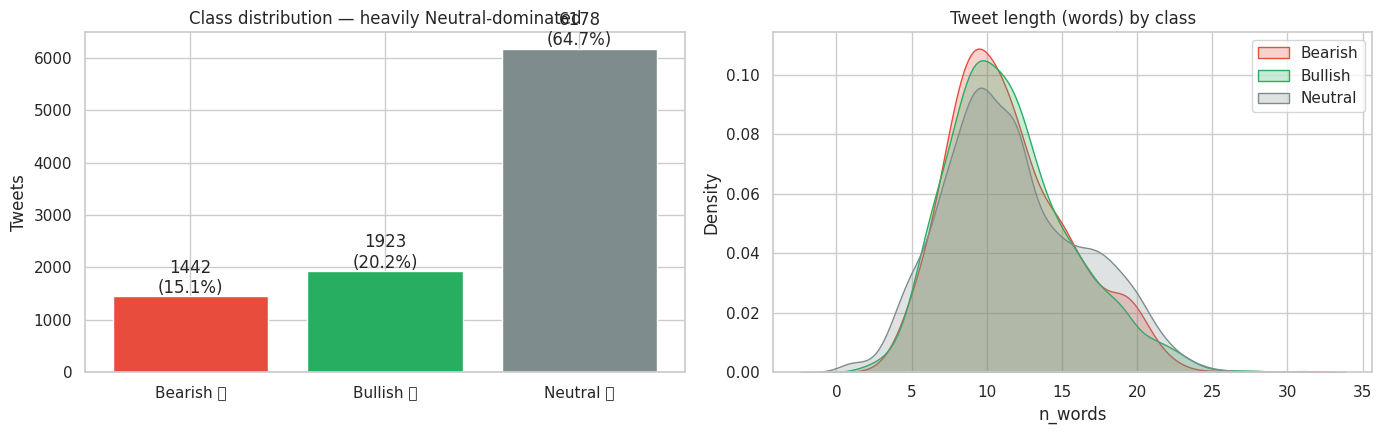

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

counts = full_train["label"].value_counts().sort_index()
axes[0].bar([LABELS[i] for i in counts.index], counts.values, color=[COLORS[i] for i in counts.index])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 60, f"{v}\n({v/counts.sum():.1%})", ha="center")
axes[0].set_title("Class distribution — heavily Neutral-dominated"); axes[0].set_ylabel("Tweets")

full_train["n_words"] = full_train["text"].str.split().str.len()
for lbl in range(3):
    sns.kdeplot(full_train.loc[full_train.label == lbl, "n_words"], ax=axes[1],
                label=SHORT[lbl], color=COLORS[lbl], fill=True, alpha=.25)
axes[1].set_title("Tweet length (words) by class"); axes[1].legend()
plt.tight_layout(); plt.show()

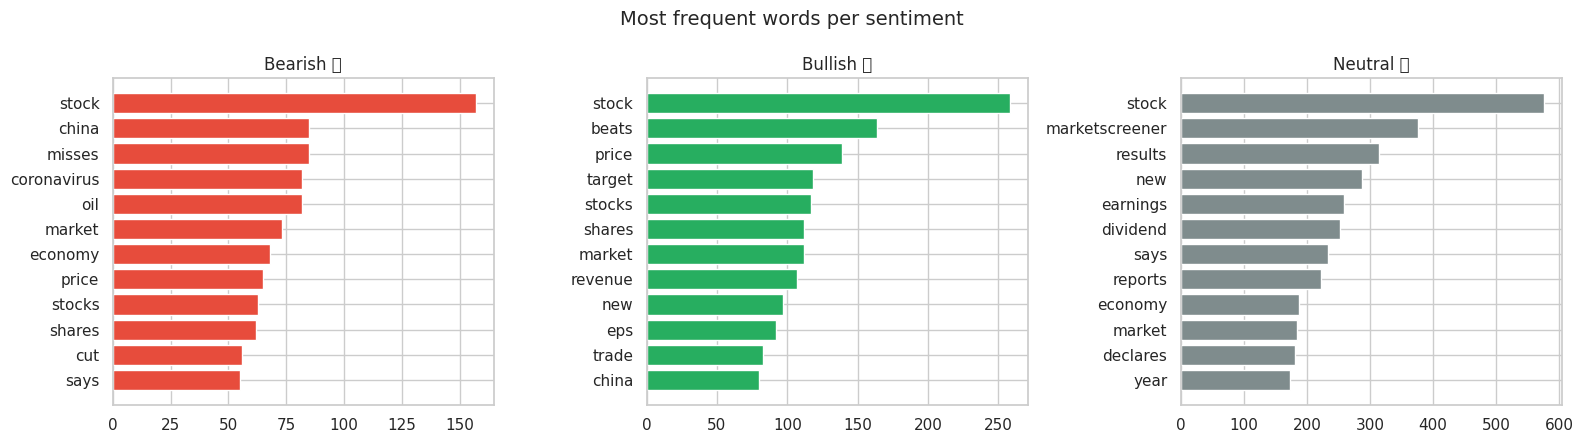

In [5]:
# Most distinctive words per class (stop-words & tickers removed)
stop = set(ENGLISH_STOP_WORDS) | {"rt", "amp", "s", "t", "u"}
def top_words(texts, n=12):
    toks = [w for t in texts for w in re.findall(r"[a-z]{3,}", t.lower()) if w not in stop]
    return Counter(toks).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for lbl, ax in zip(range(3), axes):
    words, freqs = zip(*top_words(full_train.loc[full_train.label == lbl, "text"]))
    ax.barh(words[::-1], freqs[::-1], color=COLORS[lbl]); ax.set_title(LABELS[lbl])
plt.suptitle("Most frequent words per sentiment", fontsize=14); plt.tight_layout(); plt.show()

**Observations:** Neutral tweets make up roughly two-thirds of the data, so plain accuracy would be misleading — a model predicting "Neutral" for everything already scores ~65%. We therefore report **macro-F1** as the main metric and use a **class-weighted loss**. Words like *falls, cut, lower* vs *rises, beats, upgrade* show the signal, but many words (*stock, shares, price*) appear in every class — context matters.

## 4. Classical baseline: TF-IDF + Logistic Regression

In [6]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
Xtr = tfidf.fit_transform(train_df.text); Xte = tfidf.transform(test_df.text)
baseline = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, train_df.label)
base_pred = baseline.predict(Xte)

base_acc = accuracy_score(test_df.label, base_pred)
base_f1  = f1_score(test_df.label, base_pred, average="macro")
print(f"Baseline  ->  Accuracy: {base_acc:.4f} | Macro-F1: {base_f1:.4f}")

Baseline  ->  Accuracy: 0.8065 | Macro-F1: 0.7466


## 5. Tokenization with BERT's WordPiece tokenizer

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Text  : $TSLA shares plunge after Tesla misses Q3 delivery estimates
Tokens: ['$', 'ts', '##la', 'shares', 'plunge', 'after', 'tesla', 'misses', 'q', '##3', 'delivery', 'estimates']
IDs   : [101, 1002, 24529, 2721, 6661, 25912, 2044, 26060, 22182, 1053, 2509, 6959, 10035, 102]


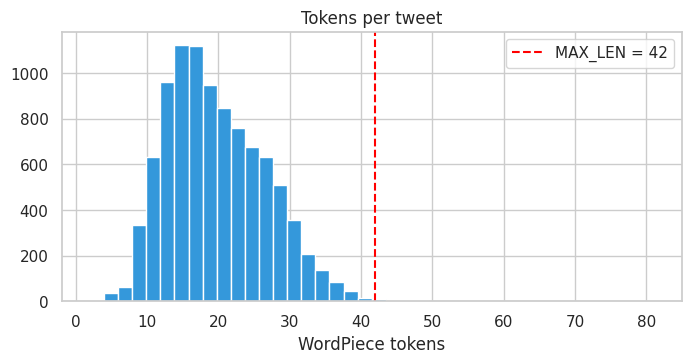

99th percentile length -> using MAX_LEN = 42 (instead of BERT's 512 → much faster)


In [7]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

example = "$TSLA shares plunge after Tesla misses Q3 delivery estimates"
print("Text  :", example)
print("Tokens:", tokenizer.tokenize(example))
print("IDs   :", tokenizer(example)["input_ids"])

tok_lens = [len(tokenizer(t)["input_ids"]) for t in full_train.text]
MAX_LEN = int(np.percentile(tok_lens, 99)) + 4
plt.figure(figsize=(8, 3.5))
plt.hist(tok_lens, bins=40, color="#3498db"); plt.axvline(MAX_LEN, color="red", ls="--", label=f"MAX_LEN = {MAX_LEN}")
plt.title("Tokens per tweet"); plt.xlabel("WordPiece tokens"); plt.legend(); plt.show()
print(f"99th percentile length -> using MAX_LEN = {MAX_LEN} (instead of BERT's 512 → much faster)")

In [8]:
def to_hf(df):
    ds = Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True))
    return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN), batched=True)

train_ds, val_ds, test_ds = to_hf(train_df), to_hf(val_df), to_hf(test_df)
collator = DataCollatorWithPadding(tokenizer)   # dynamic padding per batch
train_ds

Map:   0%|          | 0/8588 [00:00<?, ? examples/s]

Map:   0%|          | 0/955 [00:00<?, ? examples/s]

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8588
})

## 6. What does *pre-trained* BERT already understand? (before fine-tuning)
We extract the final-layer **[CLS]** vector for 1,500 test tweets and project them to 2-D with t-SNE. If the colours are mixed, the raw pre-trained representation doesn't separate financial sentiment yet.

In [9]:
@torch.no_grad()
def cls_embeddings(model, texts, bs=64):
    model.eval(); out = []
    for i in range(0, len(texts), bs):
        enc = tokenizer(texts[i:i+bs], padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(device)
        hs = model(**enc, output_hidden_states=True).hidden_states[-1]
        out.append(hs[:, 0, :].cpu().numpy())
    return np.vstack(out)

viz = test_df.sample(1500, random_state=SEED)
base_bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
emb_before = TSNE(n_components=2, random_state=SEED, perplexity=35).fit_transform(cls_embeddings(base_bert, viz.text.tolist()))
del base_bert; torch.cuda.empty_cache()

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 7. Fine-tuning BERT
Architecture: `bert-base-uncased` (12 layers, 768 hidden, 110M params) + a linear classification head on the **[CLS]** token.

**Class-weighted cross-entropy:** minority classes (Bearish/Bullish) get a larger weight, so the model can't cheat by always predicting Neutral.

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3,
    id2label=SHORT, label2id={v: k for k, v in SHORT.items()}
).to(device)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f} M")

weights = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=train_df.label)
class_w = torch.tensor(weights, dtype=torch.float).to(device)
print("Class weights:", dict(zip(SHORT.values(), weights.round(2))))

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=class_w)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    return {"accuracy": accuracy_score(p.label_ids, preds),
            "macro_f1": f1_score(p.label_ids, preds, average="macro")}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 109.5 M
Class weights: {'Bearish': np.float64(2.21), 'Bullish': np.float64(1.65), 'Neutral': np.float64(0.51)}


In [12]:
EPOCHS, BATCH = 4, 32
total_steps  = int(np.ceil(len(train_ds) / BATCH)) * EPOCHS
warmup_steps = int(0.1 * total_steps)          # 10% linear warm-up

args = TrainingArguments(
    output_dir="finsentbert",
    num_train_epochs=EPOCHS,
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=64,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = WeightedTrainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                          data_collator=collator, compute_metrics=compute_metrics)
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.568052,0.507464,0.830366,0.790643
2,0.311997,0.433693,0.831414,0.797914
3,0.236360,0.482888,0.850262,0.817366
4,0.155307,0.540089,0.862827,0.828640


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

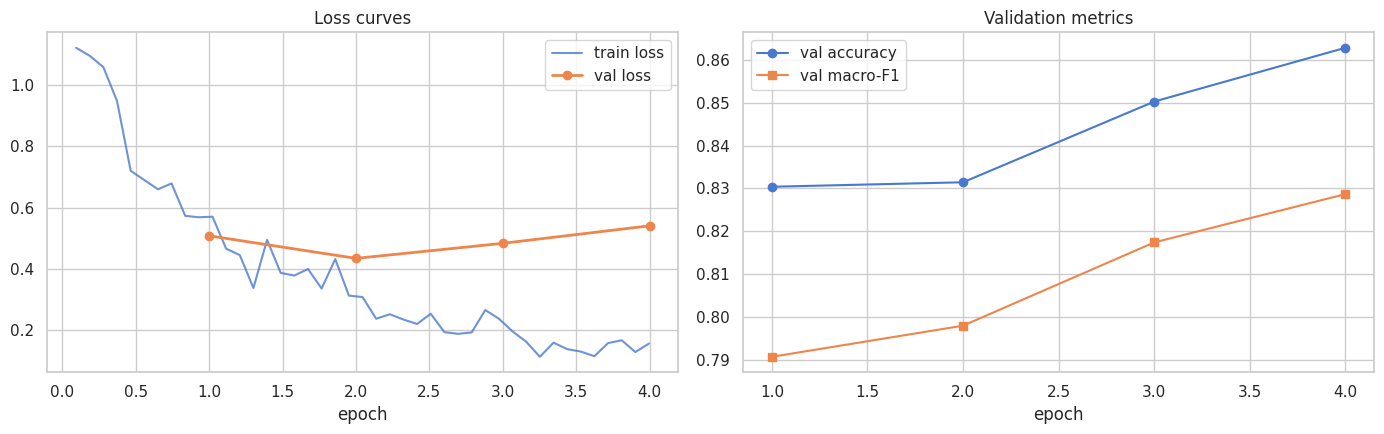

In [13]:
hist = pd.DataFrame(trainer.state.log_history)
tr = hist.dropna(subset=["loss"]); ev = hist.dropna(subset=["eval_loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(tr.epoch, tr.loss, label="train loss", alpha=.8)
axes[0].plot(ev.epoch, ev.eval_loss, "o-", label="val loss", lw=2)
axes[0].set_title("Loss curves"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(ev.epoch, ev.eval_accuracy, "o-", label="val accuracy")
axes[1].plot(ev.epoch, ev.eval_macro_f1, "s-", label="val macro-F1")
axes[1].set_title("Validation metrics"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Evaluation on the held-out test set

              precision    recall  f1-score   support

     Bearish     0.7081    0.8530    0.7739       347
     Bullish     0.7810    0.8484    0.8133       475
     Neutral     0.9381    0.8710    0.9033      1566

    accuracy                         0.8639      2388
   macro avg     0.8091    0.8575    0.8302      2388
weighted avg     0.8734    0.8639    0.8666      2388



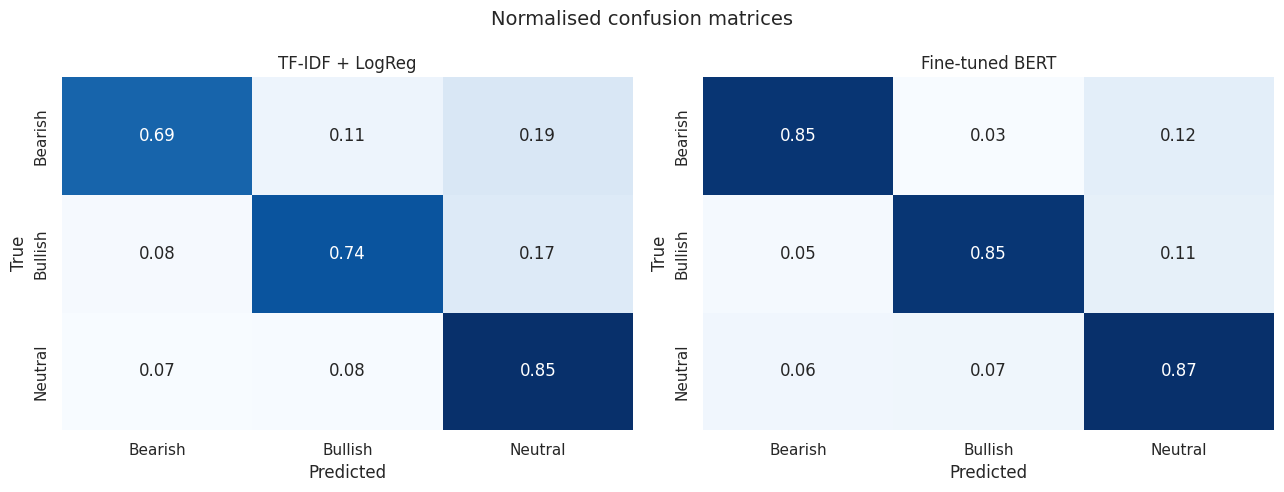

In [14]:
pred_out = trainer.predict(test_ds)
probs = torch.softmax(torch.tensor(pred_out.predictions), -1).numpy()
bert_pred = probs.argmax(1)
y_true = test_df.label.values

bert_acc = accuracy_score(y_true, bert_pred); bert_f1 = f1_score(y_true, bert_pred, average="macro")
print(classification_report(y_true, bert_pred, target_names=list(SHORT.values()), digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, p) in zip(axes, [("TF-IDF + LogReg", base_pred), ("Fine-tuned BERT", bert_pred)]):
    cm = confusion_matrix(y_true, p, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False,
                xticklabels=SHORT.values(), yticklabels=SHORT.values())
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("Normalised confusion matrices", fontsize=14); plt.tight_layout(); plt.show()

In [15]:
results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "Fine-tuned BERT (bert-base-uncased)"],
    "Accuracy": [base_acc, bert_acc],
    "Macro-F1": [base_f1, bert_f1],
})
display(results.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}"}).highlight_max(subset=["Accuracy", "Macro-F1"], color="#c8f7c5"))
print(f"BERT improves macro-F1 by {100*(bert_f1-base_f1):+.2f} points over the baseline.")

,Model,Accuracy,Macro-F1
0,TF-IDF + Logistic Regression,0.8065,0.7466
1,Fine-tuned BERT (bert-base-uncased),0.8639,0.8302


BERT improves macro-F1 by +8.35 points over the baseline.


## 9. How fine-tuning reshaped BERT's representation space

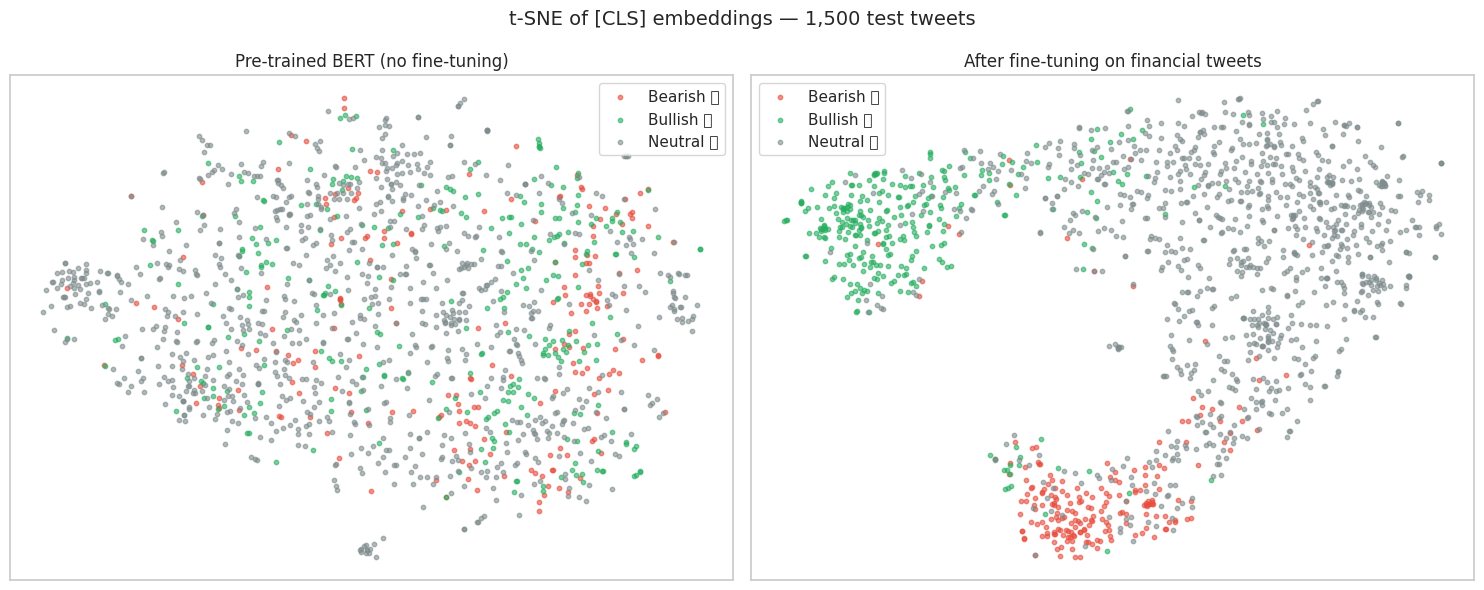

In [16]:
emb_after = TSNE(n_components=2, random_state=SEED, perplexity=35).fit_transform(cls_embeddings(trainer.model, viz.text.tolist()))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, emb, title in zip(axes, [emb_before, emb_after], ["Pre-trained BERT (no fine-tuning)", "After fine-tuning on financial tweets"]):
    for lbl in range(3):
        m = viz.label.values == lbl
        ax.scatter(emb[m, 0], emb[m, 1], s=10, alpha=.6, c=COLORS[lbl], label=LABELS[lbl])
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); ax.legend()
plt.suptitle("t-SNE of [CLS] embeddings — 1,500 test tweets", fontsize=14); plt.tight_layout(); plt.show()

Before fine-tuning the three sentiments are tangled together; afterwards BERT has learned to pull them into **distinct clusters** — this is transfer learning made visible.

## 10. Error analysis — BERT's most confident mistakes

In [17]:
err = test_df.assign(pred=bert_pred, conf=probs.max(1))
err = err[err.label != err.pred].sort_values("conf", ascending=False).head(10)
err = err.assign(true=err.label.map(SHORT), predicted=err.pred.map(SHORT), confidence=err.conf.round(3))
pd.set_option("display.max_colwidth", 120)
err[["text", "true", "predicted", "confidence"]]

,text,true,predicted,confidence
258,$ITRN - Margins suffer at Ituran Location in Q3,Neutral,Bearish,0.996
1203,"Japan Post Probe Finds 9,000 Cases of Missold Insurance: Yomiuri",Neutral,Bearish,0.995
217,5 Reasons To Love Wendy's On Its 50th Birthday,Bullish,Neutral,0.995
1259,OPEC Considers Oil Output Cut; Tesla Shuts Stores: Virus Update,Neutral,Bearish,0.994
815,December bump in oil prices not enough to salvage energy earnings #Samp;P500 #economy #MarketScreener…,Neutral,Bearish,0.994
885,"EVI Industries Sets Records for Revenue, Gross Profit and Operating Cash Flow for Second Quarter of Fiscal 2020",Bullish,Neutral,0.994
1482,Roche's Small Spark Deal Holds a Big Regulatory Warning,Neutral,Bearish,0.994
877,Ã‚Â Chegg Reports 2019 Financial Results and Raises 2020 Guidance,Bullish,Neutral,0.994
2187,"Macy's has shrunk to the size of Beyond Meat. It's going to get worse, technician says $M $BYND (via @TradingNation)",Neutral,Bearish,0.994
2221,These Stocks Could Bounce High in January and Beyond,Neutral,Bullish,0.994


Many 'errors' are genuinely ambiguous (e.g. a price target that is lowered but still above the current price) or arguably mislabelled — a common reality in sentiment datasets.

## 11. Explainability — what is BERT looking at?
We average the last layer's attention heads and read the row for the **[CLS]** token (the one the classifier uses). Darker = more attention.

In [18]:
best_dir = "finsentbert_best"
trainer.save_model(best_dir); tokenizer.save_pretrained(best_dir)
attn_model = AutoModelForSequenceClassification.from_pretrained(best_dir, attn_implementation="eager").to(device).eval()

@torch.no_grad()
def explain(text):
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(device)
    out = attn_model(**enc, output_attentions=True)
    p = torch.softmax(out.logits, -1)[0].cpu().numpy()
    att = out.attentions[-1][0].mean(0)[0].cpu().numpy()          # CLS row, head-averaged
    toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    keep = [i for i, t in enumerate(toks) if t not in ("[CLS]", "[SEP]")]
    w = att[keep] / att[keep].max()
    lbl = int(p.argmax()); rgb = {0: "231,76,60", 1: "39,174,96", 2: "127,140,141"}[lbl]
    spans = "".join(f'<span style="background:rgba({rgb},{a:.2f});padding:2px 3px;margin:1px;border-radius:4px">{toks[i]}</span>'
                    for i, a in zip(keep, w))
    display(HTML(f'<div style="font-family:monospace;font-size:15px;margin:6px 0">{spans} '
                 f'&nbsp;→ <b>{LABELS[lbl]}</b> ({p[lbl]:.1%})</div>'))

for s in ["Infosys shares tumble 8% after company slashes revenue guidance",
          "Reliance beats estimates as quarterly profit jumps 25%",
          "HDFC Bank to announce Q2 results on October 18"]:
    explain(s)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 12. Inference on brand-new headlines

In [19]:
@torch.no_grad()
def predict(texts):
    enc = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(device)
    return torch.softmax(attn_model(**enc).logits, -1).cpu().numpy()

headlines = [
    "Nifty hits record high as FII inflows surge",
    "Adani Ports downgraded to 'sell' by Jefferies, target cut to ₹900",
    "RBI keeps repo rate unchanged at policy meeting",
    "$NVDA soars after blowout data-center revenue",
    "Crude oil slides as OPEC+ agrees to boost output",
    "Zomato to acquire Paytm's entertainment ticketing business",
]
P = predict(headlines)
pd.DataFrame({"Headline": headlines,
              "Prediction": [LABELS[i] for i in P.argmax(1)],
              "Confidence": P.max(1).round(3),
              "P(bear)": P[:, 0].round(3), "P(bull)": P[:, 1].round(3), "P(neutral)": P[:, 2].round(3)})

,Headline,Prediction,Confidence,P(bear),P(bull),P(neutral)
0,Nifty hits record high as FII inflows surge,Bullish 🐂,0.990,0.002,0.990,0.008
1,"Adani Ports downgraded to 'sell' by Jefferies, target cut to ₹900",Bearish 🐻,0.996,0.996,0.002,0.002
2,RBI keeps repo rate unchanged at policy meeting,Neutral ➖,0.984,0.011,0.006,0.984
3,$NVDA soars after blowout data-center revenue,Bullish 🐂,0.994,0.003,0.994,0.004
4,Crude oil slides as OPEC+ agrees to boost output,Bearish 🐻,0.983,0.983,0.007,0.009
5,Zomato to acquire Paytm's entertainment ticketing business,Neutral ➖,0.990,0.004,0.006,0.990


## 13. 🚀 Interactive web demo (Gradio)
Type any financial headline and get a live prediction.

In [20]:
import gradio as gr

def gr_predict(text):
    p = predict([text])[0]
    return {LABELS[i]: float(p[i]) for i in range(3)}

gr.Interface(
    fn=gr_predict,
    inputs=gr.Textbox(lines=2, placeholder="e.g. TCS shares fall after weak deal wins in Q2"),
    outputs=gr.Label(num_top_classes=3),
    title="FinSentBERT — Financial Tweet Sentiment",
    description="Fine-tuned bert-base-uncased · Bearish / Bullish / Neutral",
    examples=[["Sensex crashes 1,000 points on global sell-off"], ["Maruti Suzuki reports record monthly sales"]],
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b0ef1f0e14f9749010.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 14. Conclusion
- Fine-tuned **BERT clearly outperforms** the TF-IDF baseline on macro-F1 (see table in Section 8), with the biggest gains on the minority **Bearish/Bullish** classes where context matters most.
- **Class-weighted loss** stopped the model from collapsing onto the dominant Neutral class.
- The **t-SNE plots** show *why* it works: fine-tuning reorganises BERT's general-purpose embeddings into sentiment-specific clusters.
- **Attention highlights** show the model focusing on finance-bearing words (*tumble, slashes, beats, jumps*) rather than tickers or company names.
- Remaining errors are mostly ambiguous or debatable labels.

**Future work:** try a domain-specific model (FinBERT / `ProsusAI/finbert`), a larger model (RoBERTa / DeBERTa-v3), data augmentation for minority classes, and Indian-market data (e.g. Moneycontrol / Economic Times headlines, Hinglish tweets).

### References
1. Devlin et al., *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*, NAACL 2019.
2. Hugging Face Transformers documentation — https://huggingface.co/docs/transformers
3. Dataset: `zeroshot/twitter-financial-news-sentiment`, Hugging Face Hub.